# 4D-STEM dataset generation

This notebook demonstrates the use of `cbed_simulation` to generate a 4D-STEM dataset with variable crystal orientation or lattice strain. [LiberTEM](https://github.com/LiberTEM/LiberTEM) is used for parallelisation and GPU-acceleration of the frame generation.

In [1]:
%matplotlib inline
import pathlib
import matplotlib.pyplot as plt
import numpy as np
import libertem.api as lt
from cbed_simulation.udf import build_udf_ds
from cbed_simulation.crystal_orientation import ExperimentInformation, OrientedPhase, LatticeMultipliers
from cbed_simulation.frame_builder import FrameParameters

In [2]:
ROOT_PATH = pathlib.Path(".").absolute()

LiberTEM uses a `Context` object to run computations, the following configures the Context for serial, single-cpu operation, but here is where one would specify parallelism or use of GPUs.

In [3]:
ctx = lt.Context.make_with("inline")

As with single-frame generation, we need to supply various parameters to define the simulation parameters and frame composition parameters.

In [ ]:
experiment = ExperimentInformation(
    frame_shape=(256, 256),
    pattern_scale_factor=100.,  # pixels / Å-1
    radius_px=12,
)
frame_params = FrameParameters(
    textured=False,
)
phase = OrientedPhase.from_cif(ROOT_PATH / "tests" / "Si.cif")

## Strained dataset

The first dataset is `(3, 3)` varying the `a` and `b` lattice vector lengths in Si between 0.97 and 1.03.

We need to create an array of `LatticeMultipliers` objects matching the shape of the dataset we are going to generate.

In [5]:
dim = 3

multips = np.ndarray((dim, dim), dtype=object)

for y, yv in enumerate(np.linspace(0.97, 1.03, num=dim, endpoint=True)):
    for x, xv in enumerate(np.linspace(0.97, 1.03, num=dim, endpoint=True)):
        multips[y, x] = LatticeMultipliers(a=xv, b=yv)

We use a helper function `build_udf_ds` to generate the job that will build the frames. Frames are saved to disk at the supplied path.

In [6]:
out_path = ROOT_PATH / "frames.npy"
udf, ds = build_udf_ds(
    out_path,
    (dim, dim),
    ctx,
    phase,
    experiment,
    frame_parameters=frame_params,
    lattice_mod=multips,
)

We run the job (combination of `ds` and `udf`), then load the frames to memory and delete the file (not required, just useful for this notebook).

In [7]:
try:
    res = ctx.run_udf(ds, udf, progress=True)
    assert out_path.is_file()
    frames = np.load(out_path)
finally:
    out_path.unlink(missing_ok=True)

/home/share_kiev-aar/200-Science_et_Technique/200.4-PFNC-DATA/mb265392/Workspace/libertem_dev/LiberTEM/src/libertem/io/dataset/base/partition.py:75: RuntimeWarning: dataset contains fewer frames than specified partitions, setting num_partitions == num_frames == 9 to avoid creating empty partitions
  warnings.warn(


Partitions 0/9, Frames:   0%|          | 0/9 [00:00<?, ?it/s]

We can display frames from the generated dataset, in this case the difference between the first and last frames (most strained and least strained).

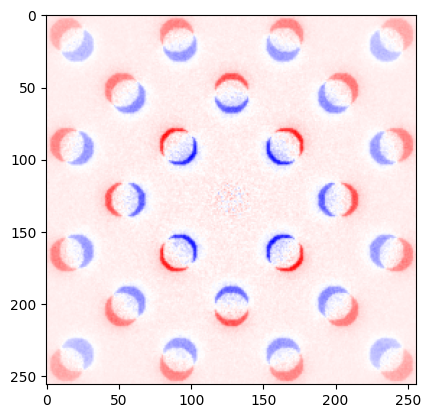

In [8]:
fig, ax = plt.subplots()
ax.imshow(frames[0, 0] - frames[-1, -1], cmap="bwr")

## Orientation dataset

The core orientation object is an [orix `Rotation`](https://orix.readthedocs.io/en/stable/reference/generated/orix.quaternion.Rotation.html). This can be used to arbitrarily orient the crystal during frame generation. `Rotation` is an array-like and can store all orientations for the desired scan shape.

In [9]:
from orix.quaternion import Rotation

We generate a `Rotation` from random Euler angles. (Though in fact `build_udf_ds` can accept a `(*nav_shape, 3)` array of Euler angles directly).

In [10]:
orientations = Rotation.from_euler(
    np.random.uniform(0, 90, size=(dim, dim, 3)),
    degrees=True,
)

In [11]:
udf, ds = build_udf_ds(
    out_path,
    (dim, dim),
    ctx,
    phase,
    experiment,
    frame_parameters=frame_params,
    orientation=orientations,
)

In [12]:
try:
    res = ctx.run_udf(ds, udf, progress=True)
    assert out_path.is_file()
    frames = np.load(out_path)
finally:
    out_path.unlink(missing_ok=True)

/home/share_kiev-aar/200-Science_et_Technique/200.4-PFNC-DATA/mb265392/Workspace/libertem_dev/LiberTEM/src/libertem/io/dataset/base/partition.py:75: RuntimeWarning: dataset contains fewer frames than specified partitions, setting num_partitions == num_frames == 9 to avoid creating empty partitions
  warnings.warn(


Partitions 0/9, Frames:   0%|          | 0/9 [00:00<?, ?it/s]

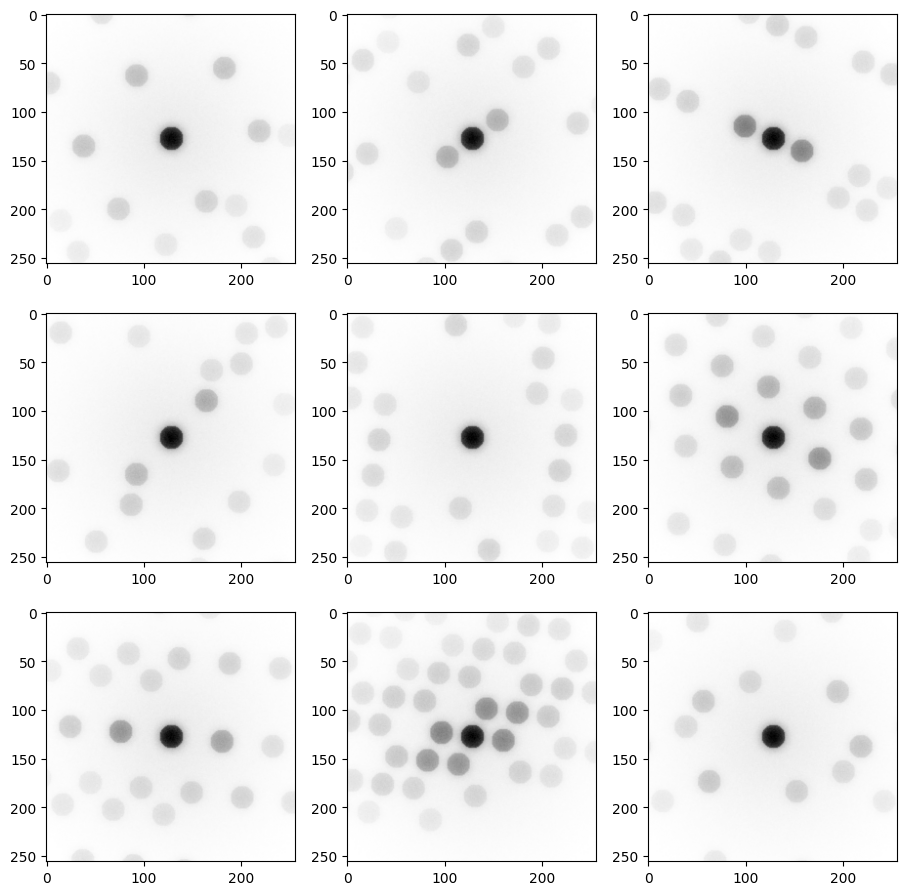

In [13]:
fig, axs = plt.subplots(dim, dim, figsize=(11, 11))
for frame, ax in zip(frames.reshape(-1, *experiment.frame_shape), axs.ravel()):
    ax.imshow(frame, cmap="gray_r")